In [1]:
import pandas as pd
from scipy import stats
from sklearn.datasets import load_breast_cancer
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = load_breast_cancer(as_frame=True).frame
df["diagnosis"] = df["target"].map({0: "malignant", 1: "benign"})

In [3]:
malignant_radius = df[df["diagnosis"] == "malignant"]["mean radius"]
benign_radius = df[df["diagnosis"] == "benign"]["mean radius"]

print("악성 mean radius 평균:", malignant_radius.mean())
print("악성 mean radius 표준편차:", malignant_radius.std())
print("양성 mean radius 평균:", benign_radius.mean())
print("양성 mean radius 표준편차:", benign_radius.std())

악성 mean radius 평균: 17.462830188679245
악성 mean radius 표준편차: 3.203971100779367
양성 mean radius 평균: 12.146523809523808
양성 mean radius 표준편차: 1.7805116461410393


In [4]:
_, p_value = stats.ttest_ind(malignant_radius, benign_radius)

print("p-value:", p_value)

p-value: 8.4659405722624e-96


In [5]:
alpha = 0.05
if p_value < alpha:
    print("귀무가설을 기각한다.")
    print("악성 종양과 양성 종양의 mean radius 평균은 같다고 보기 어렵다.")
else:
    print("귀무가설을 기각하지 못한다.")
    print("악성 종양과 양성 종양의 mean radius 평균이 다르다고 볼 수 있다.")

귀무가설을 기각한다.
악성 종양과 양성 종양의 mean radius 평균은 같다고 보기 어렵다.


In [6]:
alpha = 0.05
if p_value < alpha:
    print("귀무가설을 기각한다.")
    print("악성 종양과 양성 종양의 mean radius 평균은 같다고 보기 어렵다.")
else:
    print("귀무가설을 기각하지 못한다.")
    print("악성 종양과 양성 종양의 mean radius 평균이 다르다고 볼 수 있다.")

귀무가설을 기각한다.
악성 종양과 양성 종양의 mean radius 평균은 같다고 보기 어렵다.


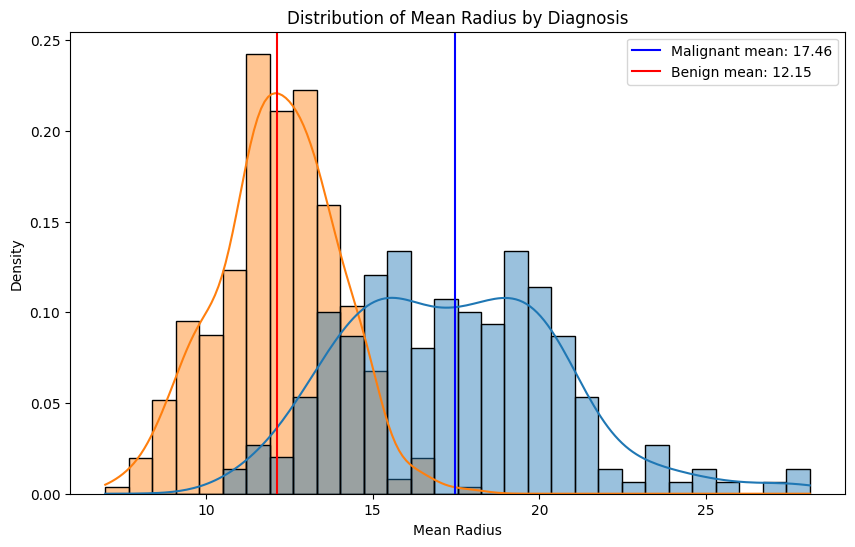

In [7]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="mean radius", hue="diagnosis", kde=True, stat="density",
common_norm=False, bins=30, alpha=0.45)
plt.axvline(malignant_radius.mean(), color="blue", label=f"Malignant mean: {malignant_radius.mean():.2f}")
plt.axvline(benign_radius.mean(), color="red", label=f"Benign mean: {benign_radius.mean():.2f}")
plt.title("Distribution of Mean Radius by Diagnosis")
plt.xlabel("Mean Radius")
plt.ylabel("Density")
plt.legend()
plt.show()

실습 1: 악성과 양성 데이터의 "mean texture"의 평균이 다른지 가설검정하고 시각화하기

In [8]:
feature = "mean texture" # mean texture, mean fractal dimension

malignant_group = df[df["diagnosis"] == "malignant"][feature]
benign_group = df[df["diagnosis"] == "benign"][feature]

print("선택한 변수:", feature)
print("- 악성 평균:", malignant_group.mean())
print("- 악성 표준편차:", malignant_group.std())
print("- 양성 평균:", benign_group.mean())
print("- 양성 표준편차:", benign_group.std())

_, p_value = stats.ttest_ind(malignant_group, benign_group)

print("\np-value:", p_value)

선택한 변수: mean texture
- 악성 평균: 21.60490566037736
- 악성 표준편차: 3.7794699207763403
- 양성 평균: 17.914761904761903
- 양성 표준편차: 3.995124593675911

p-value: 4.0586360478980125e-25


실습 2: 악성과 양성 데이터의 "mean fractal dimension"의 평균이 다른지 가설검정하고 시각화하기

- 귀무가설을 기각한다.
  -> 악성과 양성의 mean texture 평균은 같다고 보기 어렵다.


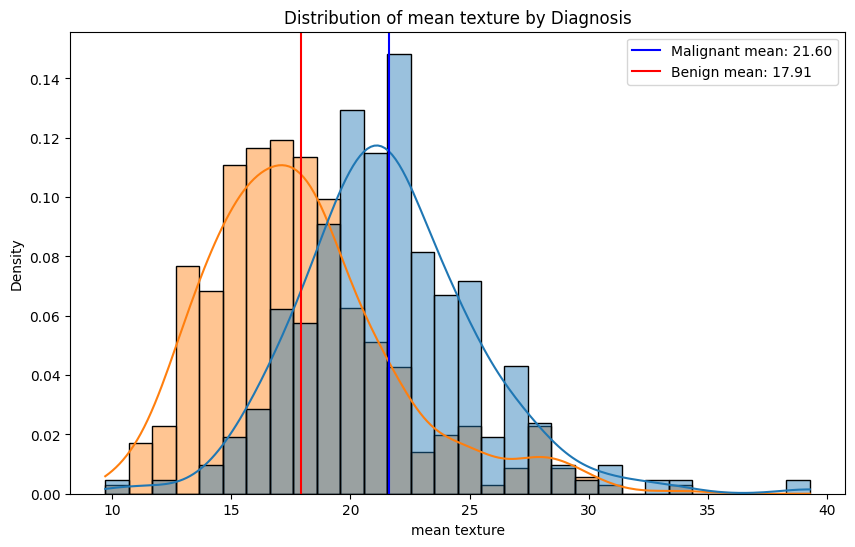

In [9]:
if p_value < alpha:
    print("- 귀무가설을 기각한다.")
    print(f"  -> 악성과 양성의 {feature} 평균은 같다고 보기 어렵다.")
else:
    print("- 귀무가설을 기각하지 못한다.")
    print(f"  -> 악성과 양성의 {feature} 평균이 다르다고 말하기 어렵다.")

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x=f"{feature}", hue="diagnosis", kde=True, stat="density",
common_norm=False, bins=30, alpha=0.45)
plt.axvline(malignant_group.mean(), color="blue", label=f"Malignant mean: {malignant_group.mean():.2f}")
plt.axvline(benign_group.mean(), color="red", label=f"Benign mean: {benign_group.mean():.2f}")
plt.title(f"Distribution of {feature} by Diagnosis")
plt.xlabel(f"{feature}")
plt.ylabel("Density")
plt.legend()
plt.show()